In [3]:
import torch
import torchvision
import cv2
import sklearn
import numpy as np
from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("CUDA version:", torch.version.cuda)
print("All imports OK")

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version: 12.1
All imports OK


In [4]:
import os

# Set folder path (NOT file)
KAGGLE_DIR = r"D:\ClarifAI"

# Create folder if not exists
os.makedirs(KAGGLE_DIR, exist_ok=True)

# Now define file path inside that folder
kaggle_json = os.path.join(KAGGLE_DIR, 'kaggle.json')

if os.path.exists(kaggle_json):
    print("kaggle.json found")
else:
    print("ERROR: Place your kaggle.json in:", KAGGLE_DIR)

kaggle.json found


In [5]:
import os
import subprocess
import zipfile
from tqdm import tqdm

KAGGLE_DIR = os.path.expanduser('~/.kaggle')
os.makedirs(KAGGLE_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)

kaggle_json = os.path.join(KAGGLE_DIR, 'kaggle.json')
if os.path.exists(kaggle_json):
    print("✓ kaggle.json found")
else:
    print("✗ ERROR: Place your kaggle.json in:", KAGGLE_DIR)
    raise FileNotFoundError("kaggle.json missing")
    

✓ kaggle.json found


In [6]:
# ── Download ──────────────────────────────────────────
print("Downloading dataset from Kaggle...")
result = subprocess.run(
    ['kaggle', 'datasets', 'download',
     '-d', 'xhlulu/140k-real-and-fake-faces',
     '-p', 'data/'],
    capture_output=False,   # streams output directly to notebook
    text=True
)
if result.returncode == 0:
    print("✓ Download complete")
else:
    print("✗ Download failed — check your kaggle.json and internet connection")

✓ Download complete


In [7]:
# ── Unzip with progress bar ───────────────────────────
ZIP_PATH    = 'data/140k-real-and-fake-faces.zip'
EXTRACT_DIR = 'data/'

print(f"Unzipping {ZIP_PATH} ...")

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    members = zf.infolist()
    total   = len(members)
    
    with tqdm(total=total, unit='file', desc='Extracting') as pbar:
        for member in members:
            zf.extract(member, EXTRACT_DIR)
            pbar.update(1)

print("✓ Extraction complete")
print("\nFolder structure:")
for split in ['train', 'valid']:
    for label in ['real', 'fake']:
        path = f'data/real_vs_fake/real-vs-fake/{split}/{label}'
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"  {split}/{label}: {count:,} images")
        else:
            print(f"  MISSING: {path}")

Unzipping data/140k-real-and-fake-faces.zip ...


Extracting: 100%|██████████████████████████████████████████████████████████| 140003/140003 [02:05<00:00, 1112.18file/s]


✓ Extraction complete

Folder structure:
  train/real: 50,000 images
  train/fake: 50,000 images
  valid/real: 10,000 images
  valid/fake: 10,000 images


train/real: 50,000 images
train/fake: 50,000 images
valid/real: 10,000 images
valid/fake: 10,000 images


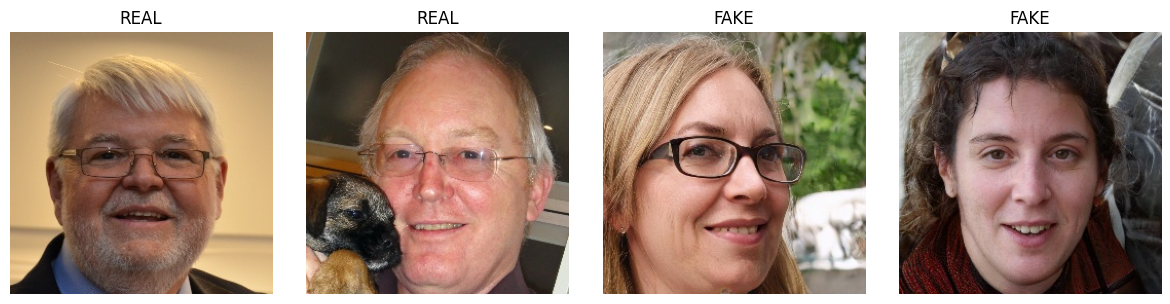

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

DATA_ROOT = 'data/real_vs_fake/real-vs-fake'

for split in ['train', 'valid']:
    for label in ['real', 'fake']:
        path = f'{DATA_ROOT}/{split}/{label}'
        if os.path.exists(path):
            print(f"{split}/{label}: {len(os.listdir(path)):,} images")
        else:
            print(f"MISSING: {path}")

# Show sample images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, label in enumerate(['real', 'real', 'fake', 'fake']):
    path = f'{DATA_ROOT}/train/{label}'
    img = Image.open(f'{path}/{random.choice(os.listdir(path))}')
    axes[i].imshow(img)
    axes[i].set_title(label.upper())
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [14]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

DATA_ROOT   = 'data/real_vs_fake/real-vs-fake'
BATCH_SIZE  = 16
IMG_SIZE    = 224
NUM_WORKERS = 0  # keep 0 on Windows

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(f'{DATA_ROOT}/train', transform=train_transform)
val_dataset   = ImageFolder(f'{DATA_ROOT}/valid', transform=val_transform)

pin = torch.cuda.is_available()  # pin_memory only useful with GPU

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)

print("Class mapping:", train_dataset.class_to_idx)
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}
Train: 100,000 | Val: 20,000
Train batches: 6250 | Val batches: 1250


In [15]:
import os
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.amp import autocast, GradScaler

DEVICE             = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ACCUMULATION_STEPS = 4
SAVE_DIR           = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

model = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)
model.classifier[1] = nn.Linear(1792, 2)
model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()
scaler    = GradScaler()

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print("Class mapping:", train_dataset.class_to_idx)
print("Ready.")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total params: 17,552,202
Class mapping: {'fake': 0, 'real': 1}
Ready.


In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

In [17]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import time

EPOCHS   = 10
best_auc = 0.0

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    train_loss = 0.0
    t0 = time.time()

    # ── Training loop with progress bar ──
    train_bar = tqdm(enumerate(train_loader), total=len(train_loader),
                     desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", leave=False)

    for step, (imgs, labels) in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast('cuda'):
            loss = criterion(model(imgs), labels) / ACCUMULATION_STEPS
        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUMULATION_STEPS
        train_bar.set_postfix(loss=f"{train_loss / (step + 1):.4f}")

    # Flush remaining gradients
    if (step + 1) % ACCUMULATION_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    # ── Validation loop with progress bar ──
    model.eval()
    all_probs, all_labels = [], []
    correct = total = 0

    val_bar = tqdm(val_loader, total=len(val_loader),
                   desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]  ", leave=False)

    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast('cuda'):
                logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total   += len(labels)
            val_bar.set_postfix(acc=f"{correct/total:.4f}")

    acc      = correct / total
    auc      = roc_auc_score(all_labels, all_probs)
    avg_loss = train_loss / len(train_loader)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | acc={acc:.4f} | AUC={auc:.4f} | "
          f"time={time.time()-t0:.0f}s")

    # ── Save checkpoint after every epoch ──
    checkpoint = {
        'epoch'           : epoch,
        'model_state_dict': model.state_dict(),
        'optim_state_dict': optimizer.state_dict(),
        'scheduler_state' : scheduler.state_dict(),
        'scaler_state'    : scaler.state_dict(),
        'class_to_idx'    : train_dataset.class_to_idx,
        'auc'             : auc,
        'acc'             : acc,
        'loss'            : avg_loss,
    }
    torch.save(checkpoint, f'{SAVE_DIR}/clarifai_epoch{epoch+1:02d}.pth')
    print(f"  💾 Checkpoint saved → clarifai_epoch{epoch+1:02d}.pth")

    # ── Save best model separately ──
    if auc > best_auc:
        best_auc = auc
        torch.save(checkpoint, f'{SAVE_DIR}/clarifai_best.pth')
        print(f"  ✓ Saved best model  (AUC={auc:.4f})")

print(f"\nDone. Best AUC: {best_auc:.4f}")

Epoch 01/10 | loss=0.2573 | acc=0.9802 | AUC=0.9984 | time=2956s
  💾 Checkpoint saved → clarifai_epoch01.pth
  ✓ Saved best model  (AUC=0.9984)


Epoch 02/10 | loss=0.1164 | acc=0.9919 | AUC=0.9998 | time=2410s
  💾 Checkpoint saved → clarifai_epoch02.pth
  ✓ Saved best model  (AUC=0.9998)


Epoch 03/10 | loss=0.0699 | acc=0.9953 | AUC=0.9999 | time=2123s
  💾 Checkpoint saved → clarifai_epoch03.pth
  ✓ Saved best model  (AUC=0.9999)


Epoch 04/10 | loss=0.0480 | acc=0.9963 | AUC=1.0000 | time=2045s
  💾 Checkpoint saved → clarifai_epoch04.pth
  ✓ Saved best model  (AUC=1.0000)


Epoch 05/10 | loss=0.0366 | acc=0.9961 | AUC=1.0000 | time=2119s
  💾 Checkpoint saved → clarifai_epoch05.pth
  ✓ Saved best model  (AUC=1.0000)


Epoch 06/10 | loss=0.0296 | acc=0.9972 | AUC=1.0000 | time=2169s
  💾 Checkpoint saved → clarifai_epoch06.pth
  ✓ Saved best model  (AUC=1.0000)


Epoch 07/10 | loss=0.0240 | acc=0.9978 | AUC=1.0000 | time=2138s
  💾 Checkpoint saved → clarifai_epoch07.pth
  ✓ Saved best model  (AUC=1.0000)


Epoch 08/10 | loss=0.0206 | acc=0.9973 | AUC=1.0000 | time=2110s
  💾 Checkpoint saved → clarifai_epoch08.pth


Epoch 09/10 | loss=0.0192 | acc=0.9977 | AUC=1.0000 | time=2178s
  💾 Checkpoint saved → clarifai_epoch09.pth
  ✓ Saved best model  (AUC=1.0000)


Epoch 10/10 | loss=0.0183 | acc=0.9983 | AUC=1.0000 | time=2074s
  💾 Checkpoint saved → clarifai_epoch10.pth
  ✓ Saved best model  (AUC=1.0000)

Done. Best AUC: 1.0000


In [20]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from facenet_pytorch import MTCNN
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
import torchvision.transforms as T
from torch.amp import autocast
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import base64, io, os

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = 'models'

# ── MTCNN ──
mtcnn = MTCNN(
    image_size=224,
    margin=20,
    keep_all=False,
    post_process=False,
    device=DEVICE
)
print("✓ MTCNN loaded")

# ── EfficientNet-B4 ──
model = efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(1792, 2)
checkpoint = torch.load(f'{SAVE_DIR}/clarifai_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

CLASS_TO_IDX = checkpoint['class_to_idx']
FAKE_IDX     = CLASS_TO_IDX['fake']

print("✓ EfficientNet-B4 loaded")
print(f"  Epochs trained : {checkpoint['epoch']+1}")
print(f"  Best AUC       : {checkpoint['auc']:.4f}")
print(f"  Best Acc       : {checkpoint['acc']:.4f}")
print(f"  Class mapping  : {CLASS_TO_IDX}")
print(f"  Fake index     : {FAKE_IDX}")

✓ MTCNN loaded
✓ EfficientNet-B4 loaded
  Epochs trained : 10
  Best AUC       : 1.0000
  Best Acc       : 0.9983
  Class mapping  : {'fake': 0, 'real': 1}
  Fake index     : 0


In [21]:
normalize = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

fallback_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

cam = GradCAM(model=model, target_layers=[model.features[-1]])

def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    face_detected = True

    # ── MTCNN face crop ──
    face_tensor = mtcnn(img)

    if face_tensor is not None:
        face_np      = face_tensor.permute(1, 2, 0).numpy().astype(np.uint8)
        face_pil     = Image.fromarray(face_np)
        input_tensor = normalize(face_pil).unsqueeze(0).to(DEVICE)
        display_img  = face_np
    else:
        face_detected = False
        input_tensor  = fallback_transform(img).unsqueeze(0).to(DEVICE)
        display_img   = np.array(img.resize((224, 224)))

    # ── EfficientNet prediction ──
    with torch.no_grad():
        with autocast('cuda'):
            logits = model(input_tensor)
        probs  = torch.softmax(logits, dim=1)
        p_fake = probs[0][FAKE_IDX].item()

    score = int(p_fake * 100)

    # ── Grad-CAM ──
    img_np_norm   = display_img.astype(np.float32) / 255.0
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    cam_image     = show_cam_on_image(img_np_norm, grayscale_cam, use_rgb=True)

    buf = io.BytesIO()
    Image.fromarray(cam_image).save(buf, format='PNG')
    heatmap_b64 = base64.b64encode(buf.getvalue()).decode()

    risk = 'Real' if score < 31 else ('Uncertain' if score < 61 else 'Likely Fake')

    return {
        'score'        : score,
        'risk'         : risk,
        'p_fake'       : round(p_fake, 4),
        'face_detected': face_detected,
        'heatmap_b64'  : heatmap_b64,
        'display_img'  : display_img,
        'cam_image'    : cam_image,
    }

print("✓ predict() ready")

✓ predict() ready


Analyzing: 00483R5CC4.jpg


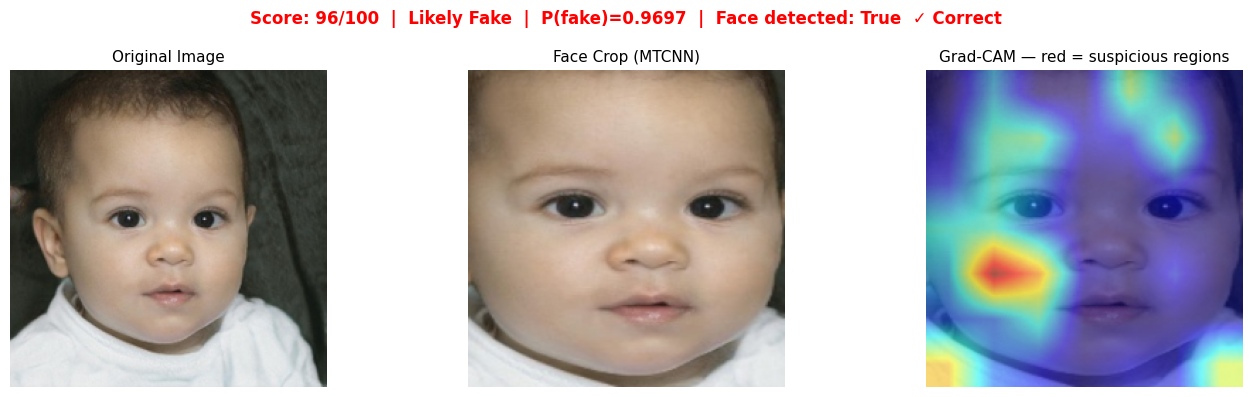

Analyzing: 00005.jpg


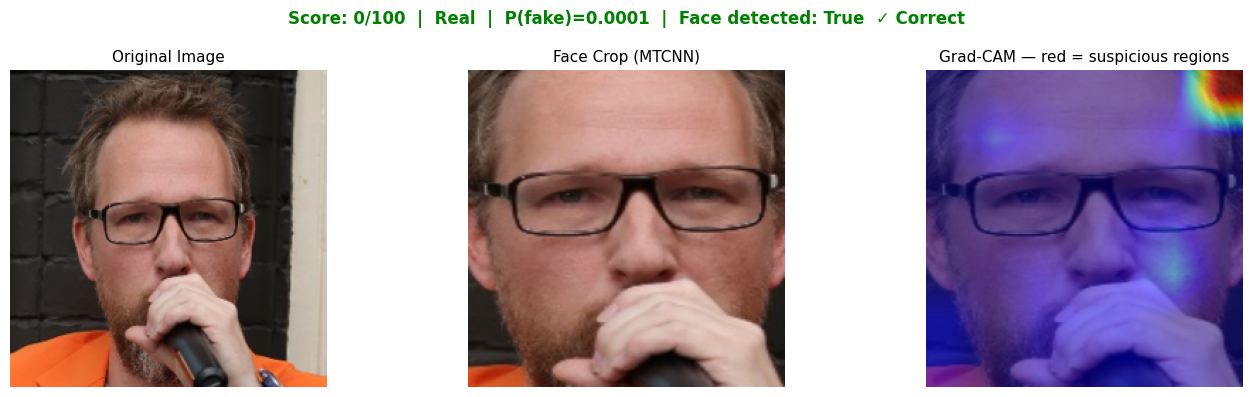

{'score': 0,
 'risk': 'Real',
 'p_fake': 0.0001,
 'face_detected': True,
 'heatmap_b64': '...',
 'display_img': array([[[ 62,  53,  48],
         [ 77,  66,  60],
         [ 99,  86,  78],
         ...,
         [ 50,  42,  39],
         [ 45,  38,  35],
         [ 41,  36,  33]],
 
        [[ 73,  63,  58],
         [ 80,  69,  62],
         [ 91,  77,  68],
         ...,
         [ 43,  37,  33],
         [ 39,  34,  31],
         [ 37,  32,  29]],
 
        [[ 91,  79,  72],
         [ 89,  76,  68],
         [ 86,  71,  62],
         ...,
         [ 35,  30,  26],
         [ 34,  29,  26],
         [ 33,  29,  26]],
 
        ...,
 
        [[212,  66,  22],
         [213,  67,  24],
         [214,  68,  27],
         ...,
         [125,  98,  87],
         [ 79,  57,  47],
         [ 49,  30,  20]],
 
        [[214,  67,  23],
         [213,  67,  24],
         [213,  67,  25],
         ...,
         [154, 126, 112],
         [102,  78,  66],
         [ 67,  45,  34]],
 
        [

In [22]:
def show_result(image_path, expected=None):
    print(f"Analyzing: {os.path.basename(image_path)}")
    result = predict(image_path)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(Image.open(image_path).resize((224, 224)))
    axes[0].set_title('Original Image', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(result['display_img'])
    axes[1].set_title(
        'Face Crop (MTCNN)' if result['face_detected'] else 'Full Image (no face)',
        fontsize=11
    )
    axes[1].axis('off')

    axes[2].imshow(result['cam_image'])
    axes[2].set_title('Grad-CAM — red = suspicious regions', fontsize=11)
    axes[2].axis('off')

    color = 'green' if result['score'] < 31 else ('orange' if result['score'] < 61 else 'red')
    status = f"  ✓ Correct" if expected and expected.lower() in result['risk'].lower() else ""

    fig.suptitle(
        f"Score: {result['score']}/100  |  {result['risk']}  |  "
        f"P(fake)={result['p_fake']}  |  "
        f"Face detected: {result['face_detected']}{status}",
        fontsize=12, color=color, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    return result

# ── Test fake ──
fake_img = 'data/real_vs_fake/real-vs-fake/valid/fake/' + \
            os.listdir('data/real_vs_fake/real-vs-fake/valid/fake/')[0]
show_result(fake_img, expected='fake')

# ── Test real ──
real_img = 'data/real_vs_fake/real-vs-fake/valid/real/' + \
            os.listdir('data/real_vs_fake/real-vs-fake/valid/real/')[0]
show_result(real_img, expected='real')

Analyzing: test.jpg


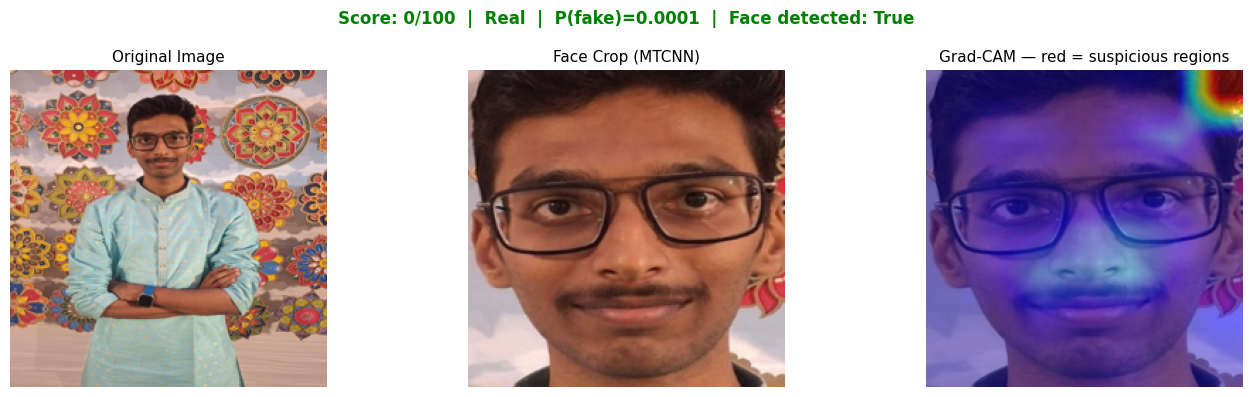

{'score': 0,
 'risk': 'Real',
 'p_fake': 0.0001,
 'face_detected': True,
 'heatmap_b64': '...',
 'display_img': array([[[221, 188, 179],
         [221, 188, 179],
         [221, 188, 179],
         ...,
         [ 47,  26,  26],
         [ 68,  45,  43],
         [ 79,  49,  46]],
 
        [[220, 187, 178],
         [220, 187, 178],
         [220, 187, 178],
         ...,
         [ 41,  20,  20],
         [ 60,  39,  37],
         [ 67,  39,  37]],
 
        [[220, 187, 178],
         [220, 187, 178],
         [220, 187, 178],
         ...,
         [ 40,  19,  21],
         [ 55,  36,  35],
         [ 51,  27,  26]],
 
        ...,
 
        [[217, 193, 191],
         [217, 193, 191],
         [219, 195, 193],
         ...,
         [175, 127,  91],
         [175, 125,  90],
         [179, 129,  94]],
 
        [[210, 185, 182],
         [211, 186, 182],
         [212, 188, 184],
         ...,
         [181, 130,  85],
         [181, 130,  85],
         [181, 130,  85]],
 
        [

In [23]:
YOUR_IMAGE = r"D:\ClarifAI\test.jpg"  # ← drop any face image here
show_result(YOUR_IMAGE)

In [24]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b4
import os

SAVE_DIR = 'models'

# Load best checkpoint
checkpoint = torch.load(f'{SAVE_DIR}/clarifai_best.pth', map_location='cpu')

# Save clean inference-only file (smaller, no optimizer state)
torch.save({
    'model_state_dict': checkpoint['model_state_dict'],
    'class_to_idx'    : checkpoint['class_to_idx'],
    'architecture'    : 'efficientnet_b4',
    'img_size'        : 224,
    'auc'             : checkpoint['auc'],
    'acc'             : checkpoint['acc'],
}, f'{SAVE_DIR}/clarifai_inference.pth')

size_mb = os.path.getsize(f'{SAVE_DIR}/clarifai_inference.pth') / (1024*1024)
print(f"✓ Exported: clarifai_inference.pth ({size_mb:.1f} MB)")
print(f"  Class mapping : {checkpoint['class_to_idx']}")
print(f"  AUC           : {checkpoint['auc']:.4f}")
print(f"  Ready for FastAPI deployment")

✓ Exported: clarifai_inference.pth (67.7 MB)
  Class mapping : {'fake': 0, 'real': 1}
  AUC           : 1.0000
  Ready for FastAPI deployment


In [25]:
import os

model_path = os.path.abspath(f'{SAVE_DIR}/clarifai_inference.pth')
print("Full path:")
print(model_path)
print()
print(f"File exists: {os.path.exists(model_path)}")
print(f"File size  : {os.path.getsize(model_path)/1024/1024:.1f} MB")

Full path:
C:\Users\admin\models\clarifai_inference.pth

File exists: True
File size  : 67.7 MB
